# Check how good mean field approx is




In [1]:
import numpy as np
np.log(40)

3.6888794541139363

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "mean_field_theory/")
from utils_mean_field import *
from script_mean_field_covid import *
os.chdir('../lattice')



e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

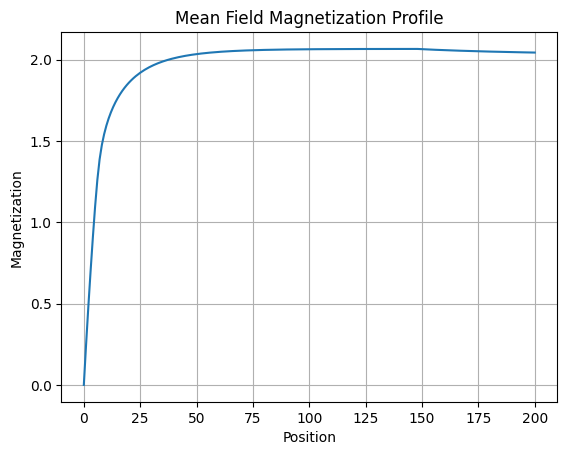

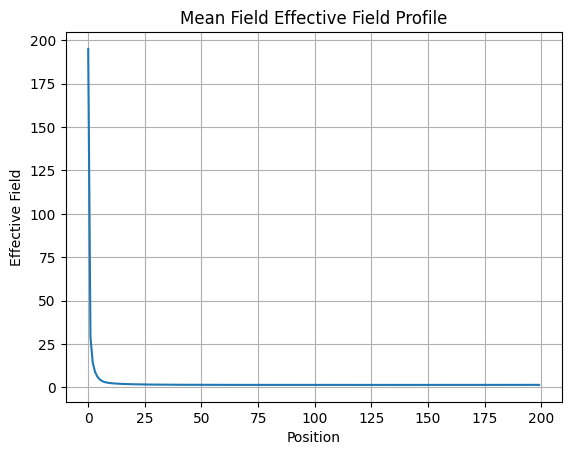

In [3]:
L=27
beta_w=10
Q_C=1

folder=f'../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_{Q_C}_beta_ab_'+str(beta_w)
mopt = np.load(f"{folder}/mopt.npy")
mopt=np.load(f"{folder}/m_array.npy")

#plot all mopt
plt.figure()
plt.plot(mopt[:,1,-1])
plt.xlabel('Position')
plt.ylabel('Magnetization')
plt.title('Mean Field Magnetization Profile')
plt.grid()
plt.show()

mhat=np.load(f"{folder}/mhat_array.npy")


#plot
plt.figure()
plt.plot(mhat[:,1,-1])
plt.xlabel('Position')
plt.ylabel('Effective Field')
plt.title('Mean Field Effective Field Profile')
plt.grid()
plt.show()


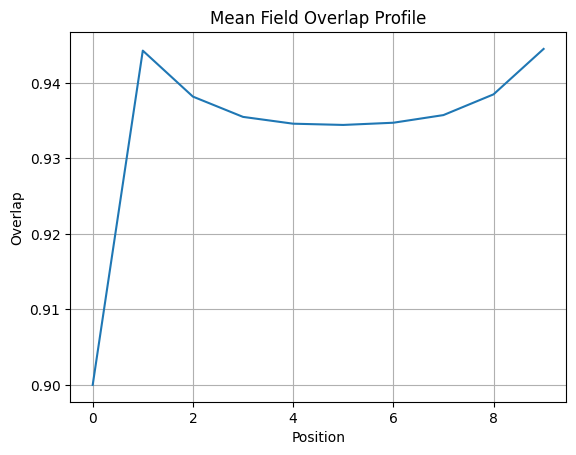

(10,)


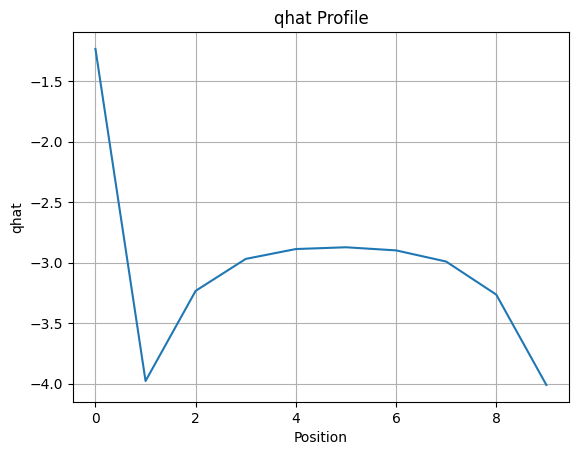

In [4]:
qopt=np.load(f"{folder}/qopt.npy")
qopt=np.load(f"{folder}/q_array.npy")[-1]
mopt=np.load(f"{folder}/m_array.npy")[-1]

#plot all qopt
plt.figure()
plt.plot(qopt)
plt.xlabel('Position')
plt.ylabel('Overlap')
plt.title('Mean Field Overlap Profile')
plt.grid()
plt.show()

qhat=np.load(f"{folder}/qhat_array.npy")[-1]
mhat=np.load(f"{folder}/mhat_array.npy")[-1]
print(qhat.shape)

#oplot
plt.figure()
plt.plot(qhat)
plt.xlabel('Position')
plt.ylabel('qhat')
plt.title('qhat Profile')
plt.grid()
plt.show()


In [5]:
qopt=np.load(f"{folder}/q_array.npy")[-1]
mopt=np.load(f"{folder}/m_array.npy")[-1]
qhat=np.load(f"{folder}/qhat_array.npy")[-1]
mhat=np.load(f"{folder}/mhat_array.npy")[-1]

In [6]:
Q_C

1

In [7]:

beta_ab=1
import torch

 # %%
RBM = RBM_utils.loadRBM("../lattice/rbm/RBM_structure_0_beta_1000")

# %%
PROTEIN_INIT = Proteins_utils.load_FASTA(
    "../lattice/msa/output_msa_structure_0_beta_1000.fasta"
)[0]  # Load the protein sequence from the FASTA file.

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
print("sites upper face", sites)
w_bias = np.zeros((PROTEIN_INIT.shape[0], 20, 1))
for site in sites:
    wt_aa = PROTEIN_INIT[site]
    print("wt_aa", Proteins_utils.num2seq(np.array([wt_aa])))
    # put a 1 everywhere except for the wt_aa
    for i in range(20):
        if i != wt_aa:
            w_bias[site, i, 0] = 1

L = PROTEIN_INIT.shape[0]
Q = 20
T = mopt.shape[0]


beta_rbm = 1

# RBM weights
wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
g = np.array(np.expand_dims(RBM.vlayer.fields[:, :], axis=-1))
#to tensor
g= torch.tensor(g, dtype=torch.float64)
print("g", g.shape)
gamma_f_list = create_gamma_functions(
    torch.tensor(RBM.hlayer.gamma_plus),
    torch.tensor(RBM.hlayer.gamma_minus),
    torch.tensor(RBM.hlayer.theta_plus),
    torch.tensor(RBM.hlayer.theta_minus),
    L,
    beta_rbm=beta_rbm,
)

all_s_functions = []
w_components = []
name_array = []

w_components.append(wgamma)
all_s_functions.extend(gamma_f_list)
name_array.extend(["gamma " + str(i) for i in range(len(gamma_f_list))])

w = torch.tensor(np.concatenate(w_components, axis=-1))

# add escape
def escape_function(G_t, beta_ab=beta_ab):
    epsilon = 0.1
    return -torch.log(1 - torch.exp(-epsilon - G_t)) * beta_ab

all_s_functions.append(escape_function)
name_array.append("escape")
w = torch.cat((w, torch.tensor(w_bias)), dim=-1)
w_components.append(w_bias)

K = len(name_array)



w = np.concatenate(w_components, axis=-1)
#to tensor
w = torch.tensor(w, dtype=torch.float64)
print("w shape", w.shape)  # L x Q x K

sites upper face [ 8  9 10 11 12 15 16 24 25]
wt_aa D
wt_aa E
wt_aa Y
wt_aa Q
wt_aa G
wt_aa P
wt_aa K
wt_aa K
wt_aa K
g torch.Size([27, 20, 1])
w shape torch.Size([27, 20, 21])


In [8]:
import torch
import numpy as np
from tqdm import tqdm

dtype=torch.float64
device=torch.device('cpu')


w.shape  # L x Q x K
mopt.shape#TxM where M nb of functions
def dZeta(mt_list, gamma_f_list, L, create_graph=True):
    """
    Compute the derivative of Zeta (mhat).
    
    Parameters:
    - create_graph: Must be True if you intend to differentiate this result again 
                    (i.e., to compute the 2nd derivative).
    """
    # 1. Ensure input requires grad to track operations
    if not mt_list.requires_grad:
        mt_list.requires_grad_(True)

    # 2. Compute the forward pass (Energy)
    # We call the clean Zeta function defined above
    energy = Zeta(mt_list, gamma_f_list, L)
    
    # 3. Compute gradients using torch.autograd.grad
    # This returns a tuple, so we take the first element [0]
    grads = torch.autograd.grad(
        outputs=energy, 
        inputs=mt_list, 
        create_graph=create_graph, # CRITICAL: Keeps the graph for 2nd derivative
        retain_graph=True,         # Often needed if differentiating same graph twice
        only_inputs=True
    )[0]
    
    return grads

def delta(v_t, v_t_plus_1):
    """
    Returns 1 if v_t != v_t_plus_1, otherwise 0.
    Pure python int comparison is fine here as v_t are indices, not tensors.
    """
    return 1 if v_t != v_t_plus_1 else 0


def compute_transfer_matrix_Z_free_second_dev(Q, q, m, w, g, v1_fixed=0, beta_rbm=1):
    """
    Compute Z using pure PyTorch to allow 2nd derivatives.
    
    Args:
        q: Tensor (T-1,) with grad
        m: Tensor (T, K) with grad
        w: Tensor (Q, K) fixed
        g: Tensor (Q,) fixed (Specific to this site i)
    """
    T = m.shape[0]


    g= g.squeeze(1)

    g_t = g.unsqueeze(0).expand(T, -1)
    


    base_val = torch.sum(m[0] * w[v1_fixed]) + g_t[0, v1_fixed] * beta_rbm
    
    T_mat_list = []
    for v2 in range(Q):
        val = delta(v1_fixed, v2) * q[0] + base_val
        T_mat_list.append(val)
    T_mat = torch.stack(T_mat_list) # Shape (Q,)

    for t in range(1, T - 1):
        new_T_mat = []
   
        
        for vp in range(Q): # Next state
            contributions = []
            for v in range(Q): # Current state
                # q[t] connects v to vp
                val = (T_mat[v] 
                       + delta(v, vp) * q[t] 
                       + torch.sum(m[t] * w[v]) 
                       + g_t[t, v] * beta_rbm)
                contributions.append(val)
            
            # LogSumExp over v
            new_T_mat.append(torch.logsumexp(torch.stack(contributions), dim=0))
        
        T_mat = torch.stack(new_T_mat)

    # Final summation over all possible states at T-1
    contributions = []
    for v in range(Q):
        val = (T_mat[v] 
               + torch.sum(m[T - 1] * w[v]) 
               + g_t[T - 1, v] * beta_rbm)
        contributions.append(val)
        
    log_Z = torch.logsumexp(torch.stack(contributions), dim=0)

    return log_Z


def get_zeta(mopt, selection_coeff_list, L):
    """
    Wraps the external Zeta function. 
    CRITICAL: Zeta must return a Tensor attached to the graph, not a numpy array.
    """
    # Assuming Zeta is imported or available globally
    # We remove .detach().numpy() and return the tensor directly.
    # We loop t inside here as per your original structure
    
    # If Zeta handles the whole tensor at once, better. 
    # If not, we map it.
    zeta_vals = []
    for j in range(mopt.shape[0]):
        # Ensure mopt[j] is kept as a tensor
        z_val = Zeta(mopt[j], selection_coeff_list, L) 
        zeta_vals.append(z_val)
        
    return torch.stack(zeta_vals)


def get_phi(qopt, q_c=Q_C, L=PROTEIN_INIT.shape[0]):
    """
    Wraps the external Phi_cont function.
    CRITICAL: Phi_cont must return a Tensor.
    """
    return Phi_cont(qopt, q_c, L)


def get_S(mhat, qhat, mopt, qopt, w, g, PROT_INIT):
    # Check for infs using torch to avoid breaking graph (though usually checks don't break it)
    if torch.any(torch.isinf(mhat)) or torch.any(torch.isinf(qhat)):
        print("mhat or qhat has inf values")
        # Returning NaN tensor to propagate error safely
        return torch.tensor(float('nan'), dtype=dtype, device=device)

    # Dot products
    sum_m_mhat = torch.sum(mhat * mopt)
    sum_q_qhat = torch.sum(qhat * qopt)
    
    sum_logZ = torch.tensor(0.0, dtype=dtype, device=device)
    
    # Loop over the protein sequence
    # Note: This loop is slow for gradients. 
    # If PROT_INIT is large, this takes time, but is correct.
    for i in range(PROT_INIT.shape[0]):
        # Pass w[i] and g[i] corresponding to site i
        logZi = compute_transfer_matrix_Z_free_second_dev(
            Q, qhat, mhat, w[i], g[i], v1_fixed=int(PROT_INIT[i]), beta_rbm=1
        )
        sum_logZ = sum_logZ + logZi

    # S = Sum(LogZ) - m*mhat - q*qhat
    s = sum_logZ - sum_m_mhat - sum_q_qhat

    
    return s

In [9]:



def get_f(mhat, qhat, mopt, qopt, w, g, PROT_INIT, selection_coeff_list_gamma):
    """
    Computes the free energy f in a fully differentiable way.
    """
    # 1. Calculate S (Entropy part)
    # Note: w and g are passed in as fixed tensors
    
    # 2. Calculate Zeta (Potential of gamma)
    # Note: get_zeta now returns a Tensor
    zeta = get_zeta(mopt, selection_coeff_list_gamma, L=PROTEIN_INIT.shape[0])
    # Sum zeta over time T to match scalar S
    zeta_sum = torch.sum(zeta) 
    
    # 3. Calculate Phi
    phi = get_phi(qopt, Q_C, L=PROTEIN_INIT.shape[0])
    phi_sum = torch.sum(phi)

    # qhat=q_hat_cont(qopt, Q_C, L=PROTEIN_INIT.shape[0])
    # mhat=m_hat(mopt, all_s_functions, L=PROTEIN_INIT.shape[0])

    s = get_S(mhat, qhat, mopt, qopt, w, g, PROT_INIT)

    # Combine
    f = -s + zeta_sum + phi_sum
    print('f ',f)
    print('s ',s)
    print('zeta', zeta_sum)

    return f

# --- Example Usage for Second Derivative ---

f=get_f(
    mhat=torch.tensor(mhat, dtype=dtype, device=device),
    qhat=torch.tensor(qhat, dtype=dtype, device=device),
    mopt=torch.tensor(mopt, dtype=dtype, device=device),
    qopt=torch.tensor(qopt, dtype=dtype, device=device),
    w=w.to(device=device, dtype=dtype),
    g=g.to(device=device, dtype=dtype),
    PROT_INIT=torch.tensor(PROTEIN_INIT, dtype=torch.long, device=device),
    selection_coeff_list_gamma=all_s_functions
)

f  tensor(-3098.5337, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7124, dtype=torch.float64)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)


In [10]:
mopt

array([[ 0.89848393, -2.22520232, -1.15748751,  0.49875173, -0.27730244,
         1.55367172,  1.33748591,  0.53395349,  0.7909947 , -0.07505695,
        -0.67561227,  1.48922765, -0.99887347, -0.25913274,  0.04827823,
        -1.5312593 , -0.85450125, -0.92974651, -0.95834041,  0.22579539,
         0.        ],
       [-0.31951592, -0.0057546 , -2.40124092,  2.23657012,  3.41198925,
         3.24731737,  1.11861195,  2.00740259, -0.25260269, -2.29385517,
         0.5272168 ,  2.70836722, -1.92533285,  0.40525826, -3.72561183,
        -1.50779343, -3.25301069, -3.40953745, -0.80788005,  1.37865338,
         2.04441609],
       [-0.37637255,  0.11638806, -2.42160261,  2.29729587,  3.49983902,
         3.38033104,  1.260309  ,  2.25594256, -0.19817783, -2.48852662,
         0.60265417,  2.67489354, -1.98817517,  0.35394037, -3.90639433,
        -1.70059804, -3.32828226, -3.67251607, -0.85703492,  1.38012221,
         2.03837705],
       [-0.41383592,  0.14833027, -2.43576063,  2.2953763 

In [11]:
import torch

import torch
import numpy as np
from tqdm import tqdm  # specific import for progress bar

def print_derivs(target_val, param, target_name, param_name):
    """
    1. Computes the Gradient (1st Deriv) for the whole tensor.
    2. Iterates to compute the EXACT Hessian Diagonal (2nd Deriv) for every element.
    3. Prints global statistics (Mean, Std, Ratio) to check for exponential behavior.
    """
    print(f"\n" + "="*40)
    print(f"--- Analyzing {target_name} vs {param_name} ---")

    # --- 1. First Derivative (Gradient) ---
    grad_1 = torch.autograd.grad(
        target_val, 
        param, 
        create_graph=True, 
        retain_graph=True, 
        allow_unused=True 
    )[0]

    if grad_1 is None:
        print(f"Gradient is None (No dependency between {target_name} and {param_name})")
        return

    # Flatten for easier iteration and statistics
    flat_grad = grad_1.view(-1)
    flat_param = param.view(-1)
    num_elements = flat_grad.numel()

    print(f"Shape: {param.shape} | Computing Hessian Diag for {num_elements} elements...")

    # --- 2. Second Derivative (Full Diagonal Loop) ---
    hess_diag_elements = []
    
    # We must loop because we need d(grad_i)/d(param_i) specifically
    # tqdm adds a progress bar because this can be slow for large tensors
    for i in tqdm(range(num_elements), desc=f"Hessian Diag ({param_name})", leave=False):
        grad_2 = torch.autograd.grad(
            flat_grad[i],       # The gradient at index i
            param,              # The full parameter tensor
            retain_graph=True, 
            allow_unused=True
        )[0]
        
        if grad_2 is not None:
            # We only care about the effect of param[i] on grad[i]
            # So we extract the i-th element of the resulting gradient-of-gradient
            val = grad_2.view(-1)[i]
            hess_diag_elements.append(val)
        else:
            hess_diag_elements.append(torch.tensor(0.0, device=param.device))

    # Reassemble Hessian Diagonal
    hess_diag = torch.stack(hess_diag_elements)

    # --- 3. Statistical Analysis ---
    
    # Detach to numpy for calculations
    g_np = flat_grad.detach().cpu().numpy()
    h_np = hess_diag.detach().cpu().numpy()
    
    # Calculate Ratio: Grad / Hessian
    # Filter out near-zero hessians to avoid Inf/NaN
    mask = np.abs(h_np) > 1e-9
    if np.any(mask):
        ratios = g_np[mask] / h_np[mask]
        avg_ratio = np.mean(ratios)
        std_ratio = np.std(ratios)
    else:
        avg_ratio = 0.0
        std_ratio = 0.0

    print(f"\n>>> STATISTICS:")
    print(f"1st Deriv (Grad)      | Mean: {np.mean(g_np):.6f} | Std: {np.std(g_np):.6f}")
    print(f"2nd Deriv (Hess Diag) | Mean: {np.mean(h_np):.6f} | Std: {np.std(h_np):.6f}")
    print(f"RATIO (1st / 2nd)     | Mean: {avg_ratio:.4f}     | Std: {std_ratio:.4f}")

    
    print("-" * 40 + "\n")
    return hess_diag


def get_f_bis(mopt, qopt, w, g, PROT_INIT, selection_coeff_list_gamma):
    # Ensure inputs track gradients
    if not mopt.requires_grad: mopt.requires_grad_(True)
    if not qopt.requires_grad: qopt.requires_grad_(True)

    # 1. Zeta
    zeta = get_zeta(mopt, selection_coeff_list_gamma, L=PROT_INIT.shape[0])
    zeta_sum = torch.sum(zeta) 

    # 2. Phi
    phi = get_phi(qopt, Q_C, L=PROT_INIT.shape[0])
    phi_sum = torch.sum(phi)

    # 3. mhat / qhat computation
    qhat_computed = q_hat_cont(qopt, Q_C, L=PROT_INIT.shape[0])
    
    m_hat_list=[]
    for t in range(T):
        # Ensure we pass the tensor element mopt[t]
        m_hat_list.append(-dZeta(mopt[t], selection_coeff_list_gamma, L=PROT_INIT.shape[0]))
    mhat_computed = torch.stack(m_hat_list, dim=0)
    
    # 4. S
    s = get_S(mhat_computed, qhat_computed, mopt, qopt, w, g, PROT_INIT)

    # 5. Free Energy
    f = -s + zeta_sum + phi_sum

    print("\n" + "#"*40)
    print(f"COMPUTED VALUES: f={f.item():.4f}")
    print("#"*40)

    # --- PRINT ROBUST DERIVATIVES ---
    # We call the new function which iterates over the full tensors
    
    # Zeta depends only on m
    # print_derivs(zeta_sum, mopt, "zeta", "m")
    
    # # Phi depends only on q
    # print_derivs(phi_sum, qopt, "phi", "q")

    # # S depends on both
    # print_derivs(s, qopt, "s", "q")
    # print_derivs(s, mopt, "s", "m")

    # Total F
    hess_diag_q=print_derivs(f, qopt, "f", "q")
    print(hess_diag_q)

    hess_diag_m=print_derivs(f, mopt, "f", "m")
    print(hess_diag_m)
    
    return hess_diag_m, hess_diag_q

Hm, Hq=get_f_bis(
    mopt=torch.tensor(mopt, dtype=dtype, device=device),
    qopt=torch.tensor(qopt, dtype=dtype, device=device),
    w=w.to(device=device, dtype=dtype),
    g=g.to(device=device, dtype=dtype),
    PROT_INIT=torch.tensor(PROTEIN_INIT, dtype=torch.long, device=device),
    selection_coeff_list_gamma=all_s_functions
)



########################################
COMPUTED VALUES: f=-2975.1166
########################################

--- Analyzing f vs q ---
Shape: torch.Size([10]) | Computing Hessian Diag for 10 elements...



>>> STATISTICS:
1st Deriv (Grad)      | Mean: 8.027303 | Std: 125.034317
2nd Deriv (Hess Diag) | Mean: -6514.364233 | Std: 6570.673457
RATIO (1st / 2nd)     | Mean: 0.0073     | Std: 0.0094
----------------------------------------

tensor([ 10766.8969, -14792.7466,  -8317.4632,  -6503.8034,  -5953.7799,
         -5814.9991,  -5917.4186,  -6412.9567,  -8089.4822, -14107.8895],
       dtype=torch.float64)

--- Analyzing f vs m ---
Shape: torch.Size([11, 21]) | Computing Hessian Diag for 231 elements...



>>> STATISTICS:
1st Deriv (Grad)      | Mean: 0.094891 | Std: 0.690085
2nd Deriv (Hess Diag) | Mean: -0.140194 | Std: 6.585781
RATIO (1st / 2nd)     | Mean: 0.2704     | Std: 1.8737
----------------------------------------

tensor([  0.3866,   0.3949,   0.3575,   0.3923,   0.3891,   0.3983,   0.2283,
          0.4041,   0.4132,   0.4224,   0.3277,   0.2584,   0.4091,   0.3828,
          0.3592,   0.3683,   0.3936,   0.3899,   0.3612,   0.3698, -99.9167,
          0.3799,   0.3879,   0.3207,   0.3582,   0.3447,   0.3842,   0.2619,
          0.3591,   0.3643,   0.3776,   0.3476,   0.2577,   0.3626,   0.3785,
          0.4375,   0.3427,   0.3636,   0.3480,   0.3527,   0.3193,  -1.0277,
          0.3816,   0.3846,   0.3230,   0.3603,   0.3484,   0.3855,   0.2620,
          0.3549,   0.3691,   0.3778,   0.3543,   0.2615,   0.3636,   0.3845,
          0.4409,   0.3489,   0.3667,   0.3509,   0.3535,   0.3221,  -1.0534,
          0.3820,   0.3838,   0.3232,   0.3615,   0.3504,   0.3865,   0.2

In [12]:
import torch
import matplotlib.pyplot as plt
PROT_INIT=torch.tensor(PROTEIN_INIT, dtype=torch.long, device=device),

def get_hessian_diagonal(target_scalar, param, param_name):
    """
    Computes the exact diagonal of the Hessian matrix for a given scalar target 
    with respect to a parameter tensor.
    
    Returns:
        grad_1: First derivative (Gradient) - same shape as param
        hess_diag: Second derivative (Diagonal of Hessian) - same shape as param
    """
    print(f"--- Computing Hessian Diagonal for {param_name} ---")
    
    # 1. Compute First Derivative (Gradient)
    # create_graph=True is vital to differentiate this again
    grad_1 = torch.autograd.grad(
        target_scalar, 
        param, 
        create_graph=True, 
        retain_graph=True, 
        allow_unused=True
    )[0]
    
    if grad_1 is None:
        print(f"No dependency found for {param_name}")
        return None, None

    # Flatten the tensors to loop over them easily
    grad_1_flat = grad_1.view(-1)
    param_flat_len = grad_1_flat.size(0)
    
    hess_diag_elements = []
    
    # 2. Loop through every element to compute the 2nd derivative of that specific element
    # This loop isolates the diagonal term, ignoring off-diagonal interactions.
    print(f"Iterating over {param_flat_len} elements... (this might take a moment)")
    
    for i in tqdm(range(param_flat_len)):
        # Take the gradient of the i-th component of the first derivative
        # w.r.t the ORIGINAL parameter tensor
        grad_2 = torch.autograd.grad(
            grad_1_flat[i], 
            param, 
            retain_graph=True,
            allow_unused=True
        )[0]
        
        # We only care about the i-th element of this new gradient 
        # (The derivative of df/dx_i with respect to x_i)
        if grad_2 is not None:
            hess_diag_elements.append(grad_2.view(-1)[i])
        else:
            hess_diag_elements.append(torch.tensor(0.0, device=param.device, dtype=param.dtype))

    # Stack and reshape back to original shape
    hess_diag = torch.stack(hess_diag_elements).view_as(param)
    
    return grad_1, hess_diag

def analyze_curvature(grad, hess, name):
    """
    Visualizes the relationship between Gradient and Hessian Diagonal.
    """
    if grad is None or hess is None: return

    # Detach for plotting
    g_np = grad.detach().cpu().numpy().flatten()
    h_np = hess.detach().cpu().numpy().flatten()
    
    print(f"\nStats for {name}:")
    print(f"Grad Mean: {g_np.mean():.4e} | Std: {g_np.std():.4e}")
    print(f"Hess Mean: {h_np.mean():.4e} | Std: {h_np.std():.4e}")
    
    # Calculate Ratio (avoiding division by zero)
    # We add a tiny epsilon or mask zeros
    mask = h_np != 0
    ratios = g_np[mask] / h_np[mask]
    print(f"Mean Ratio (Grad/Hess): {ratios.mean():.4f}")

    # Plot
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(g_np, h_np, alpha=0.5, s=10)
    plt.xlabel(f"Gradient (dF/d{name})")
    plt.ylabel(f"Hessian Diag (d2F/d{name}2)")
    plt.title(f"{name}: First vs Second Derivative")
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(ratios, bins=50, range=(ratios.mean()-2*ratios.std(), ratios.mean()+2*ratios.std()))
    plt.xlabel("Ratio (Grad / Hess)")
    plt.title("Histogram of Ratios")
    
    plt.tight_layout()
    plt.show()

# 1. Run your function to get 'f' and build the graph


In [13]:
mopt.shape

(11, 21)

In [14]:
mhat[1]

array([-0.09937309, -0.08468653, -0.79950605,  0.75392268,  1.08637035,
        1.19290453,  0.3954614 ,  0.7520624 ,  0.03551869, -0.71948224,
        0.22641208,  0.85563531, -0.62918662,  0.16615746, -1.16531727,
       -0.45436629, -0.9857668 , -1.12550768, -0.31214212,  0.35674314,
        1.40395134])

In [15]:
# f_val = get_f(mhat_t, qhat_t, m_var+0.1, q_var, w, g, torch.tensor(PROTEIN_INIT), all_s_functions)
# f_val

In [16]:
import numpy as np
import matplotlib.pyplot as plt
def analyze_second_derivative(valid_factors, f_values):
# 1. Get data from your function
    factors_arr = np.array(valid_factors)
    values_arr = np.array(f_values)

    # 2. Fit a 2nd degree polynomial (Parabola)
    # Returns coefficients [a, b, c] for ax^2 + bx + c
    coeffs = np.polyfit(factors_arr, values_arr, 2)
    a = coeffs[0]

    # 3. Calculate Second Derivative
    # The second derivative of ax^2 is 2a
    second_derivative_est = 2 * a

    print(f"--- Results ---")
    print(f"Quadratic Coefficient (a): {a:.4f}")
    print(f"Estimated Second Derivative: {second_derivative_est:.4f}")

    # --- Verification Plot ---
    # Create a smooth curve based on the fit to visually verify
    fit_curve = np.polyval(coeffs, factors_arr)
    fit_arr=np.linspace(min(factors_arr), max(factors_arr), 100)
    fit_curve= np.polyval(coeffs, fit_arr)
    plt.figure(figsize=(8, 5))
    plt.plot(factors_arr, values_arr, 'o', label='free energy', color='blue')
    plt.plot(fit_arr, fit_curve, '-', label=f'Quad Fit (2nd Deriv={second_derivative_est:.2f})', color='orange')
    plt.title("Verifying Curvature Estimation")
    plt.xlabel("Factor (Delta)")
    plt.ylabel("f Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return second_derivative_est



Starting sweep...
fac -0.01
f  tensor(-3098.5329, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7116, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
fac -0.005
f  tensor(-3098.5333, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7120, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
fac 0.0
f  tensor(-3098.5337, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7124, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
fac 0.004999999999999999
f  tensor(-3098.5340, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7128, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7390, dtype=torch.float64, grad_fn=<SumBackward0>)
fac 0.01
f  tensor(-3098.5344, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7132, dtype=torch.float64, grad_f

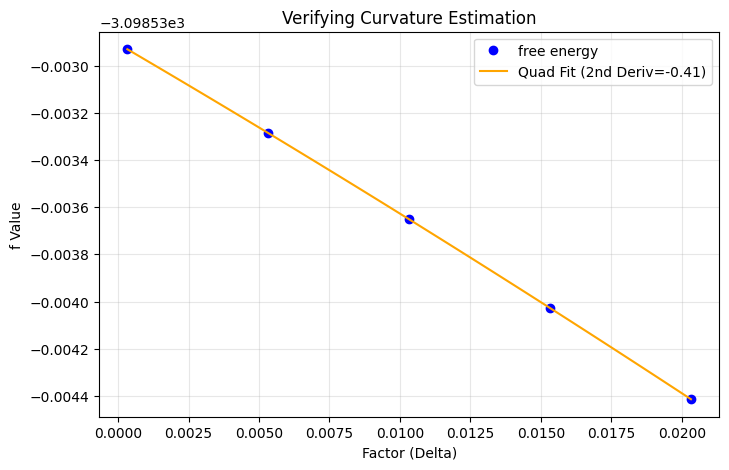

In [17]:

def run_f_sweep():
    mhat_t = torch.tensor(mhat, dtype=dtype, device=device, requires_grad=False) # Fixed
    qhat_t = torch.tensor(qhat, dtype=dtype, device=device, requires_grad=False) # Fixed

    # mopt and qopt are the variables we differentiate with respect to
    m_var = torch.tensor(mopt, dtype=dtype, device=device, requires_grad=True)
    q_var = torch.tensor(qopt, dtype=dtype, device=device, requires_grad=True)
    # Define the range of factors from -0.2 to +0.1
    # We use 100 steps for a smooth curve
    factors = np.linspace(-0.01, 0.01, 5)
    
    valid_factors = []
    f_values = []
    
    print("Starting sweep...")
    all_tested=[]
    for factor in factors:
        print ('fac',factor )
        # Convert numpy array to tensor first (good practice)
        #cr
       
        factor_arr = torch.zeros_like(m_var)

        # 2. Set the specific index (t, id) to the current factor
        # Ensure you have defined t (0-6) and id (0-20) beforehand
        t=-1
        id=1
        factor_arr[t, id] = factor

        # 3. Perform the out-of-place addition
        m_var_adjusted = m_var + factor_arr
        # m_var_adjusted=m_var
        all_tested.append(m_var_adjusted[t, id].detach().numpy())


        try:
            # Call the function using the adjusted q_var
            # Ensuring PROTEIN_INIT is a tensor as per your snippet
            val_tensor = get_f(
                mhat_t, 
                qhat_t, 
                m_var_adjusted, 
                q_var, 
                w, 
                g, 
                torch.tensor(PROTEIN_INIT), 
                all_s_functions
            )
            
            # Extract scalar value from tensor if necessary
            val = val_tensor.item() if isinstance(val_tensor, torch.Tensor) else val_tensor

            # Check for Infinity
            if val == float('inf') or np.isinf(val):
                print(f"Break: Infinity encountered at factor {factor:.4f}")
                break
            
            # Store results
            valid_factors.append(factor)
            f_values.append(val)
            
        except Exception as e:
            print(f"Error computing f at factor {factor:.4f}: {e}")
            break
    return all_tested, f_values

if __name__ == "__main__":
    valid_factors, f_values=run_f_sweep()
    analyze_second_derivative(valid_factors, f_values)



Starting sweep...
f  tensor(-3098.5320, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.6925, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
f  tensor(-3098.5332, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7025, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
f  tensor(-3098.5337, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7124, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
f  tensor(-3098.5332, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7224, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, grad_fn=<SumBackward0>)
f  tensor(-3098.5317, dtype=torch.float64, grad_fn=<AddBackward0>)
s  tensor(2768.7323, dtype=torch.float64, grad_fn=<SubBackward0>)
zeta tensor(-331.7391, dtype=torch.float64, g

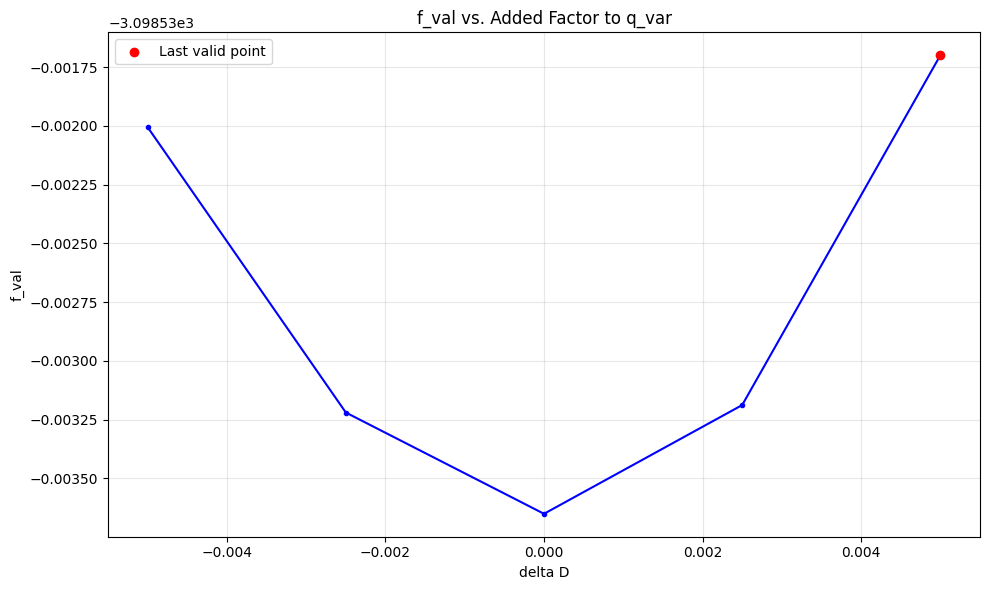

--- Results ---
Quadratic Coefficient (a): 72.0267
Estimated Second Derivative: 144.0533


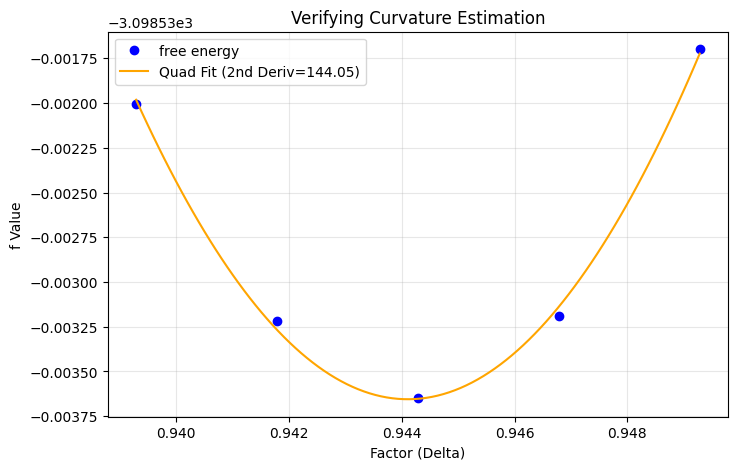

In [18]:
mhat_t = torch.tensor(mhat, dtype=dtype, device=device, requires_grad=False) # Fixed
qhat_t = torch.tensor(qhat, dtype=dtype, device=device, requires_grad=False) # Fixed

# mopt and qopt are the variables we differentiate with respect to
m_var = torch.tensor(mopt, dtype=dtype, device=device, requires_grad=True)
q_var = torch.tensor(qopt, dtype=dtype, device=device, requires_grad=True)
def run_f_sweep():
    # Define the range of factors from -0.2 to +0.1
    # We use 100 steps for a smooth curve
    factors = np.linspace(-0.005, 0.005, 5)
    
    valid_factors = []
    f_values = []
    all_factors=[]
    print("Starting sweep...")

    for factor in factors:
        t=1
        # Convert numpy array to tensor first (good practice)
        # factor_arr = torch.tensor([0, factor, 0, 0, 0, 0], device=q_var.device, dtype=q_var.dtype)
        factor_arr=torch.zeros_like(q_var)
        factor_arr[t]=factor
        # Use standard addition, creating a NEW tensor
        q_var_adjusted = q_var + factor_arr
        all_factors.append(q_var_adjusted[t].item())

        try:
            # Call the function using the adjusted q_var
            # Ensuring PROTEIN_INIT is a tensor as per your snippet
            val_tensor = get_f(
                mhat_t, 
                qhat_t, 
                m_var, 
                q_var_adjusted, 
                w, 
                g, 
                torch.tensor(PROTEIN_INIT), 
                all_s_functions
            )
            
            # Extract scalar value from tensor if necessary
            val = val_tensor.item() if isinstance(val_tensor, torch.Tensor) else val_tensor

            # Check for Infinity
            if val == float('inf') or np.isinf(val):
                print(f"Break: Infinity encountered at factor {factor:.4f}")
                break
            
            # Store results
            valid_factors.append(factor)
            f_values.append(val)
            
        except Exception as e:
            print(f"Error computing f at factor {factor:.4f}: {e}")
            break

    # Plotting results
    plt.figure(figsize=(10, 6))
    plt.plot(valid_factors, f_values, marker='.', linestyle='-', color='b')
    
    plt.title(f'f_val vs. Added Factor to q_var')
    plt.xlabel('delta D')
    plt.ylabel('f_val')
    plt.grid(True, alpha=0.3)
    
    # Add a text annotation for the start/end
    if valid_factors:
        plt.scatter(valid_factors[-1], f_values[-1], color='red', zorder=5, label='Last valid point')
        plt.legend()

    plt.tight_layout()
    plt.show()
    return all_factors, f_values

if __name__ == "__main__":
    all_factors, f_values=run_f_sweep()
    analyze_second_derivative(all_factors, f_values)

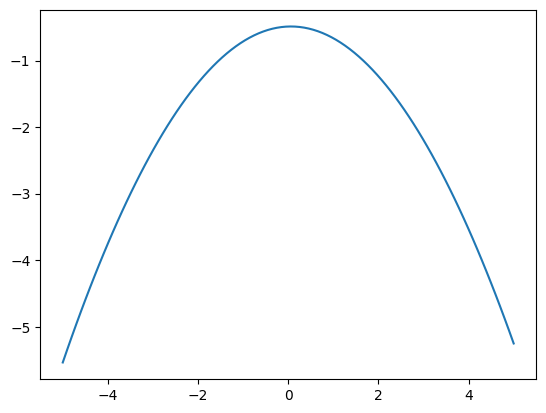

In [19]:
function=all_s_functions[0]
values=torch.linspace(-5,5,100)
outputs=[function(value).item() for value in values]
plt.plot(values, outputs)